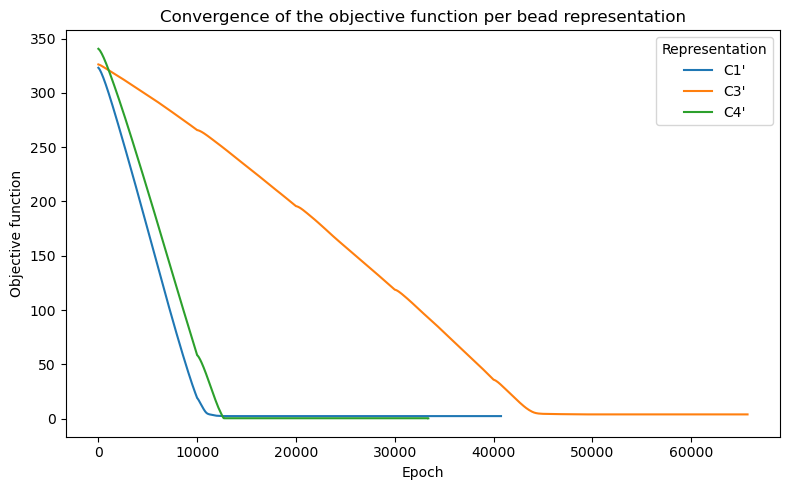

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "C1'": "folding/vis_Seq_1_182003_857761_2523776_C1'/folding_vis.csv",
    "C3'": "folding/vis_Seq_1_181401_934019_2418315_C3'/folding_vis.csv",
    "C4'": "folding/vis_Seq_1_181437_587294_2431438_C4'/folding_vis.csv",
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, path in files.items():
    df = pd.read_csv(path)
    ax.plot(df["epoch"], df["score"], label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Objective function")
ax.set_title("Convergence of the objective function per bead representation")
ax.legend(title="Representation")
plt.tight_layout()
plt.savefig("score_comparison.png", dpi=300)
plt.show()


In [8]:
from pymol import cmd, util
import pymol

if "pymol_launched" not in globals():
    pymol.finish_launching(['pymol', '-qc'])  # -q: quiet, -c: pas d'interface graphique
    pymol_launched = True


def render_pdb_to_png(pdb_path, output_png, nom_objet="structure",
                       width=1200, height=1200, dpi=300, ray=True):
    cmd.reinitialize()
    cmd.load(pdb_path, nom_objet)

    cmd.hide("everything", nom_objet)
    cmd.show_as("spheres", nom_objet)
    util.cbaw(nom_objet)

    cmd.bg_color("white")
    cmd.set("ray_opaque_background", 0)
    cmd.orient(nom_objet)
    cmd.zoom(nom_objet, buffer=2)

    cmd.png(output_png, width=width, height=height, dpi=dpi, ray=int(ray))


render_pdb_to_png("folding/vis_Seq_1_182003_857761_2523776_C1'/best_structure_full_atom.pdb", "predicted_structure_C1.png")
